In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import pandas as pd
df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
df.head()
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [3]:
df.info()
df.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [4]:
df.shape


(891, 12)

In [5]:
df.size

10692

In [6]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df["Age"] = df["Age"].fillna (df["Age"].median())

In [8]:
df["Cabin"] = df["Cabin"].fillna(df["Cabin"].mode()[0])

In [9]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       2
dtype: int64

In [10]:
print("Before duplicated:",df.duplicated().sum())

Before duplicated: 0


In [11]:
df = df.drop_duplicates()


In [12]:
print("Duplicate after removing :",df.duplicated().sum())

Duplicate after removing : 0


In [13]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [14]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [15]:
df.drop(columns =["PassengerId","Ticket","Cabin","Name"],axis=1,inplace=True)


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


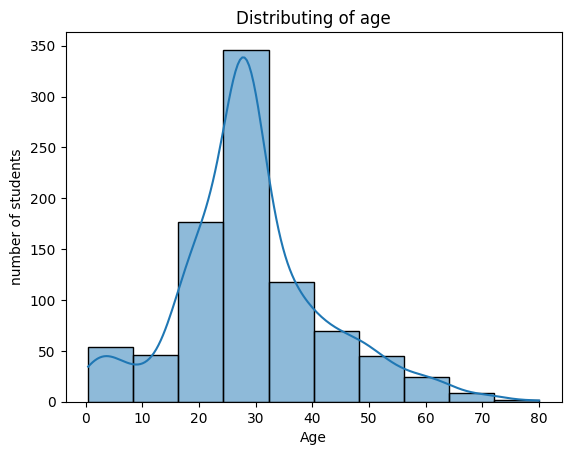

In [18]:
import matplotlib. pyplot as plt
import seaborn as sns
sns.histplot(df["Age"],bins=10,kde=True)
plt.title("Distributing of age")
plt.xlabel("Age")
plt.ylabel("number of students")
plt.show()

In [19]:
df = pd.get_dummies(
    df,
    columns=["Sex","Embarked"],
             dtype = int
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_female  891 non-null    int64  
 7   Sex_male    891 non-null    int64  
 8   Embarked_C  891 non-null    int64  
 9   Embarked_Q  891 non-null    int64  
 10  Embarked_S  891 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 76.7 KB


In [20]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0,1,0,0,1
1,1,1,38.0,1,0,71.2833,1,0,1,0,0
2,1,3,26.0,0,0,7.9250,1,0,0,0,1
3,1,1,35.0,1,0,53.1000,1,0,0,0,1
4,0,3,35.0,0,0,8.0500,0,1,0,0,1


In [21]:
from sklearn.model_selection import train_test_split
x = df.drop("Survived",axis=1)
y = df["Survived"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [23]:
from sklearn.linear_model import LinearRegression
lr =  LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

In [24]:
from sklearn.metrics import  mean_absolute_error,mean_squared_error,r2_score
print("MSE :",mean_squared_error(y_test,y_pred))
print("MAE :",mean_absolute_error(y_test,y_pred))
print("r2_score:",r2_score(y_test,y_pred))


MSE : 0.1508546612241744
MAE : 0.30495440159419956
r2_score: 0.36317072460029354


In [25]:
from sklearn.neighbors import KNeighborsRegressor
knn_reg = KNeighborsRegressor(n_neighbors = 5)
knn_reg.fit(x_train,y_train)
y_pred = knn_reg.predict(x_test)

In [26]:
from sklearn.metrics import  mean_absolute_error,mean_squared_error,r2_score
print("MSE :",mean_squared_error(y_test,y_pred))
print("MAE :",mean_absolute_error(y_test,y_pred))
print("r2_score:",r2_score(y_test,y_pred))


MSE : 0.1456983240223464
MAE : 0.27262569832402234
r2_score: 0.38493807641633726


In [27]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(
    criterion = "squared_error",
    max_depth = 10,
    random_state = 42
)
dt.fit(x_train,y_train)
y_pred = dt.predict(x_test)



In [28]:
from sklearn.metrics import  mean_absolute_error,mean_squared_error,r2_score
print("MSE :",mean_squared_error(y_test,y_pred))
print("MAE :",mean_absolute_error(y_test,y_pred))
print("r2_score:",r2_score(y_test,y_pred))


MSE : 0.17858716203501473
MAE : 0.23015380371060074
r2_score: 0.24609864838420203


In [29]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0,1,0,0,1
1,1,1,38.0,1,0,71.2833,1,0,1,0,0
2,1,3,26.0,0,0,7.9250,1,0,0,0,1
3,1,1,35.0,1,0,53.1000,1,0,0,0,1
4,0,3,35.0,0,0,8.0500,0,1,0,0,1


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_female  891 non-null    int64  
 7   Sex_male    891 non-null    int64  
 8   Embarked_C  891 non-null    int64  
 9   Embarked_Q  891 non-null    int64  
 10  Embarked_S  891 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 76.7 KB


In [31]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(x_train,y_train)
y_pred = lor.predict(x_test)

In [32]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("Accuracy :",accuracy_score(y_test,y_pred))
print("confusion_matrix :",confusion_matrix(y_test,y_pred))
print("classification_report :",classification_report(y_test,y_pred))



Accuracy : 0.8044692737430168
confusion_matrix : [[98 12]
 [23 46]]
classification_report :               precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [33]:
from sklearn.neighbors import KNeighborsClassifier
knn_classifer = KNeighborsClassifier(n_neighbors = 81)
knn_classifer.fit(x_train,y_train)
y_pred = knn_classifer.predict(x_test)

In [34]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("Accuracy :",accuracy_score(y_test,y_pred))
print("confusion_matrix :",confusion_matrix(y_test,y_pred))
print("classification_report :",classification_report(y_test,y_pred))


Accuracy : 0.776536312849162
confusion_matrix : [[98 12]
 [28 41]]
classification_report :               precision    recall  f1-score   support

           0       0.78      0.89      0.83       110
           1       0.77      0.59      0.67        69

    accuracy                           0.78       179
   macro avg       0.78      0.74      0.75       179
weighted avg       0.78      0.78      0.77       179

